# Exact early-time model

In [ ]:
from ipynb_boilerplate import *
from crocodil.theory.system_a.early import EarlyTimeSimilarityModel

PARAM_KEYS = ('Ra', 'Da')
PARAMS_FIXED = SYSTEM_A_REFERENCE.remove(*PARAM_KEYS)

simulations_batch = GridSimulationFromNPZ.dict_from_dir_paths(
    PARAM_KEYS, 
    SIM_DIR_PATHS,
    ('c', 's'),
    ('f', 'mD', 'mC', 'uRMS'),
    PARAMS_FIXED,
    lazy=True,
    sorting=lambda d: dict(sorted(d.items(), reverse=False)),
)
save_fig = partial(
    save_figure, 
    dir_path=DIR_FIGS, 
    prefix='EarlyExact', 
    pickle=True,
    file_ext=('svg', 'png'),
)

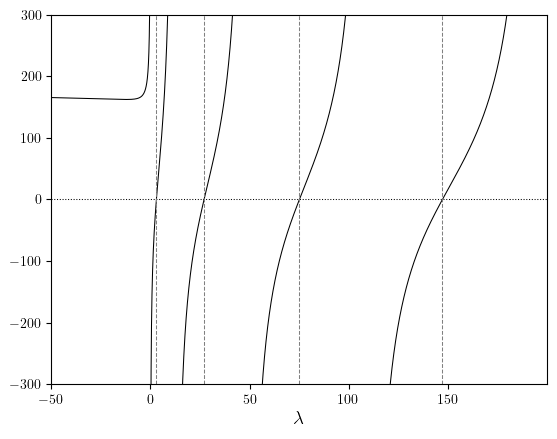

In [1]:
import numpy as np
from lucifex.plt import plot_line
from crocodil.dns.system_a import SYSTEM_A_REFERENCE
from crocodil.theory.system_a.early import EarlyTimeExactModel, EarlyTimeExactFormulae

X = 1
Ra, Da, zeta0, sr, cr, aspect = SYSTEM_A_REFERENCE['Ra', 'Da', 'zeta0', 'sr', 'cr', 'aspect']
Lmbda = EarlyTimeExactFormulae.Lmbda(Ra, Da, sr)

lmbda_axis = np.arange(-50, 200, 0.01)
lmbda_curve = np.array(
    [EarlyTimeExactFormulae.eigenvalue_characteristic(i, Lmbda, zeta0) for i in lmbda_axis]
)
lmbda_curve[np.abs(lmbda_curve) > 1e3] = np.nan

eigen_guesses = range(1, int(max(lmbda_axis)), 5)
eigenvalues = EarlyTimeExactFormulae.eigenvalues(
    Lmbda, zeta0, eigen_guesses,
)

fig, ax = plot_line(
    (lmbda_axis, lmbda_curve),
    x_label='$\lambda$',
)
y_lims = (-300, 300)
ax.set_ylim(*y_lims)
ax.hlines(0, min(lmbda_axis), max(lmbda_axis), linestyles='dotted', colors='black', linewidths=0.75)
ax.vlines(eigenvalues, *y_lims, linestyles='dashed', colors='grey', linewidths=0.75)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$c_{\\mathrm{b}}$', ylabel='$y$'>)

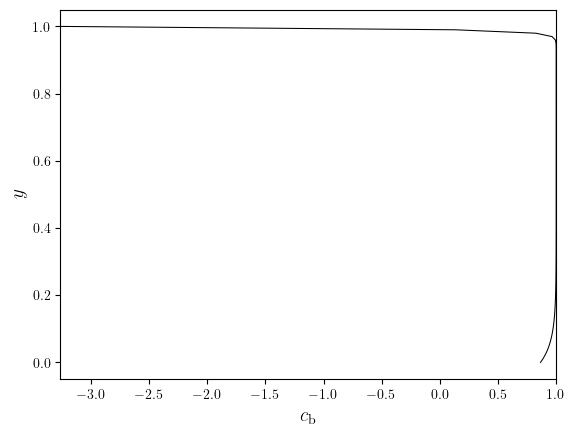

In [2]:
t = np.linspace(1e-6, 120.0, 100)
y = np.linspace(0, X, 100)
exact_model = EarlyTimeExactModel(t, y, Ra, Da, zeta0, sr, cr, eigen_guesses)

# slc = slice(0, None, 5)
# plot_line(
#     [(exact_model.y, i) for i in exact_model.c[slc]],
#     cyc='jet',
#     legend_title='$t$',
#     legend_labels=(min(exact_model.t), max(exact_model.t)),
#     flip=True,
# )

plot_line(
    (exact_model.y, exact_model.c(10.0)),
    flip=True,
    x_label='$c_{\mathrm{b}}$',
    y_label='$y$',
)

In [ ]:
exact_model.coefficients

[2.714852034154549e-07,
 2.7190571821617454e-07,
 2.597728155289433e-07,
 6.442076238715982e-08,
 -2.8606734164605247e-07]

: 

(<Figure size 640x480 with 1 Axes>, <Axes: ylabel='$y$'>)

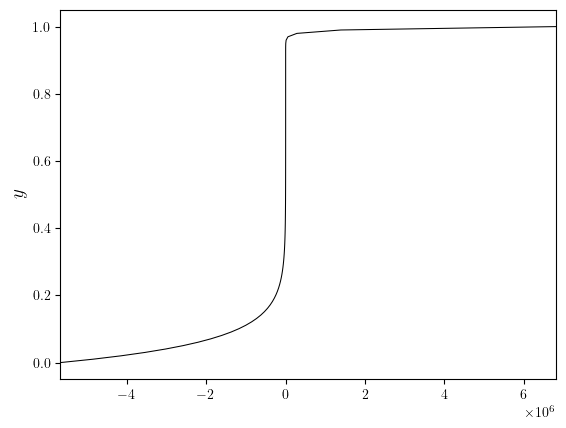

In [6]:
Ln = eigenvalues[-1]

plot_line(
    (exact_model.y, [EarlyTimeExactFormulae.Yn(i, Ln, Lmbda, zeta0) for i in exact_model.y]),
    flip=True,
    y_label='$y$',
)

In [3]:
exact_model.eigenvalues

array([  3.00380779,  27.03420964,  75.09469037, 147.18460192,
       243.30296698])